# Theta vs Random


1. **Načtou se data**

2. **Nastavení**

3. **Random metoda**

4. **Theta metoda**

5. **Pro každou metodu se fituje SAPCE model**

6. **Zkouší se více konfigurací modelu**

7. **Spočítají se chyby**

8. **Vykreslí se grafy**

In [4]:
import copy
import random
import traceback
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from UQpy.distributions import Normal, Uniform, JointIndependent
from UQpy.sampling.ThetaCriterionPCE import ThetaCriterionPCE

import SAPCE


In [5]:
# Načtení dat - ze souboru

# Práh pro odstranění (skoro) konstantních výstupů. U_251_1 v Oakwood.csv má
# std ≈ 1.58e-5 (999 z 1000 hodnot je přesně 0) - takový výstup rozbíjí
# relativní/normalizovanou validační chybu uvnitř SAPCE (dělení téměř nulou
# -> NaN) a tím shodí VŠECHNY konfigurace v gridu, bez ohledu na
# degree_list/cond_list/ratio_list/cr_list. Práh 5e-5 leží bezpečně mezi
# U_251_1 (1.58e-5, zahodit) a dalším nejmenším std v datasetu (1.47e-4,
# ponechat).
MIN_OUTPUT_STD = 5e-5


def load_dataset(data_file, min_output_std=MIN_OUTPUT_STD, verbose=True):
    data = pd.read_csv(data_file, sep=";", header=0)

    for col in data.columns:
        # OPRAVA: dtype == object nechytí sloupce s pandas "string" dtype
        # (novější pandas čte sloupce s čárkou jako desetinným oddělovačem
        # rovnou jako dtype "str", ne "object"), takže se čárka->tečka
        # konverze u nich vůbec nespustila a X pak obsahoval text.
        # is_numeric_dtype spolehlivě pozná všechny nečíselné varianty.
        if not pd.api.types.is_numeric_dtype(data[col]):
            data[col] = pd.to_numeric(
                data[col].astype(str).str.replace(",", ".", regex=False),
                errors="raise"
            )

    # OPRAVA: vynucen float, aby arr nezůstal dtype=object
    arr = data.to_numpy(dtype=float)
    X = arr[:, :12]
    Y_full = arr[:, 12:]
    y_col_names = list(data.columns[12:])

    if X.shape[1] != 12:
        raise ValueError(f"Dataset {data_file} has {X.shape[1]} input columns, expected 12")

    if Y_full.shape[1] == 0:
        raise ValueError(f"Dataset {data_file} has no output columns after the first 12 columns")

    # OPRAVA: odstranění (skoro) konstantních výstupů - viz komentář u MIN_OUTPUT_STD.
    stds = Y_full.std(axis=0)
    keep_mask = stds >= min_output_std
    dropped = [name for name, keep in zip(y_col_names, keep_mask) if not keep]

    if verbose and dropped:
        print(
            f"[load_dataset] {data_file}: odstraněno {len(dropped)} "
            f"(skoro) konstantních výstupů (std < {min_output_std}): {dropped}"
        )

    Y = Y_full[:, keep_mask]

    if Y.shape[1] == 0:
        raise ValueError(
            f"Dataset {data_file}: po odstranění (skoro) konstantních výstupů "
            f"nezbyl žádný výstupní sloupec."
        )

    # ZMĚNA ZDE: Vracíme i keep_mask, y_col_names a Y_full pro pozdější doplnění nul
    return X, Y, keep_mask, y_col_names, Y_full


In [6]:
# ============================================================
# OVĚŘENÍ OPRAVY
# ============================================================
# 1) load_dataset() vrací čistě numerická pole (float64) i pro sloupce,
#    které dřív zůstaly jako text (Erat_1, k0_1, Erat_2, E50_2, c_2, k0_2).
# 2) (Skoro) konstantní výstupy (jako U_251_1: 999 z 1000 hodnot = 0) jsou
#    automaticky vyřazeny, protože jinak dělají NaN ve validation_error
#    a shazují úplně všechny konfigurace v gridu.

_X_check, _Y_check, _keep_mask, _y_col_names, _Y_full = load_dataset("Oakwood.csv")

print("X dtype:", _X_check.dtype, "| X shape:", _X_check.shape)
print("Y dtype:", _Y_check.dtype, "| Y shape:", _Y_check.shape)

assert _X_check.dtype == np.float64, "X není float64 - konverze se stále nepovedla!"
assert _Y_check.dtype == np.float64, "Y není float64 - konverze se stále nepovedla!"
assert _X_check.shape[1] == 12, f"X má {_X_check.shape[1]} sloupců, čekáno 12"
assert not np.isnan(_X_check).any(), "X obsahuje NaN po konverzi"
assert not np.isnan(_Y_check).any(), "Y obsahuje NaN po konverzi"

_y_stds = _Y_check.std(axis=0)
assert np.all(_y_stds >= MIN_OUTPUT_STD), (
    f"V Y zbyl výstup s příliš malým std: min std = {_y_stds.min():.3e} "
    f"(práh {MIN_OUTPUT_STD:.3e})"
)

print("\nOK - všechny vstupní i výstupní sloupce jsou správně převedené na čísla,")
print("a žádný zbývající výstup není (skoro) konstantní.")
print("Prvních 12 hodnot prvního řádku X (měly by to být čísla, ne text):")
print(_X_check[0])
print(f"\nPočet výstupů po vyřazení degenerovaných sloupců: {_Y_check.shape[1]} "
      f"(očekáváno 22, protože U_251_1 se vyřadí)")


[load_dataset] Oakwood.csv: odstraněno 1 (skoro) konstantních výstupů (std < 5e-05): ['U_251_1']
X dtype: float64 | X shape: (1000, 12)
Y dtype: float64 | Y shape: (1000, 22)

OK - všechny vstupní i výstupní sloupce jsou správně převedené na čísla,
a žádný zbývající výstup není (skoro) konstantní.
Prvních 12 hodnot prvního řádku X (měly by to být čísla, ne text):
[ 12.    53.     2.2   74.    22.    30.     0.62   2.8  130.     4.3
  43.     0.58]

Počet výstupů po vyřazení degenerovaných sloupců: 22 (očekáváno 22, protože U_251_1 se vyřadí)


Nastavení

In [8]:
# Nastavení
DATA_FILES = [
    "Oakwood.csv",
]

SEED = 1
N_REPEATS = 1
TEST_SIZE = 300

# velikosti trénovací množiny
nsim = np.arange(15, 100, 10)

# Grid - pro různé soubor může být výhodné jiné nastavení Sapce, proto hledám nejlepsí nastavení
degree_list = [2, 3, 5]
cond_list = [10,100,1000]
cr_list = [1e-8]
ratio_list = [0.30, 0.40, 0.50, 0.70]

METHODS = ["Random", "Theta"]

# Theta zvolení kolik výstupů uvidí, none = všechny
# None = použije všechny výstupy daného datasetu.
THETA_OUTPUT_INDICES = None

# KPro kontrolu převodu PCE
VERIFY_PCE_CONVERSION = True
PCE_VERIFY_ATOL = 1e-8
PCE_VERIFY_RTOL = 1e-6

n_inputs = 12
linear_terms = n_inputs + 1


In [9]:
# Rozdělení vstupů
marg = [
    Normal(13, 1),
    Uniform(30, 40),
    Uniform(2, 1),
    Normal(65, 5),
    Normal(30, 5),
    Normal(30, 1),
    Uniform(0.6, 0.5),
    Uniform(2, 1),
    Normal(130, 10),
    Normal(5, 1),
    Normal(42, 1),
    Uniform(0.45, 0.2)
]

joint = JointIndependent(marginals=marg)


In [10]:

# Univerzální predikce PCE objektu.
def predict_pce(pce, X_in):
    X_in = np.asarray(X_in, dtype=float)

    for name in ["predict", "evaluate", "run"]:
        if hasattr(pce, name):
            try:
                return np.asarray(getattr(pce, name)(X_in))
            except TypeError:
                pass

    if callable(pce):
        return np.asarray(pce(X_in))

    raise AttributeError("PCE object has no usable prediction method")


# Převod multi-output PCE na list jedno-výstupových PCE.
def pce_multioutput_to_singleoutput_list(pce, output_indices=None):
    coef = np.asarray(pce.coefficients)

    if coef.ndim == 1:
        coef = coef.reshape(-1, 1)

    n_outputs = coef.shape[1]

    if output_indices is None:
        output_indices = range(n_outputs)
    else:
        output_indices = [int(i) for i in output_indices]

    pce_list = []

    for j in output_indices:
        if j < 0 or j >= n_outputs:
            raise IndexError(f"output index {j} out of range")

        pce_j = copy.deepcopy(pce)
        pce_j.coefficients = coef[:, [j]]
        pce_list.append(pce_j)

    return pce_list


# Hlavní funkce pro ThetaCriterionPCE.
def select_theta_points_from_sapce(
    sapce,
    existing_samples,
    candidate_samples,
    nsamples=1,
    candidate_indices=None,
    output_indices=None,
    pce_weights=None,
    samples_weights=None,
    candidate_weights=None,
    verify_conversion=True,
    x_verify=None,
    atol=1e-8,
    rtol=1e-6,
):
    existing_samples = np.asarray(existing_samples, dtype=float)
    candidate_samples = np.asarray(candidate_samples, dtype=float)

    if candidate_samples.shape[0] == 0:
        raise ValueError("candidate_samples is empty")

    nsamples = int(nsamples)
    nsamples = max(1, min(nsamples, candidate_samples.shape[0]))

    pce_list = pce_multioutput_to_singleoutput_list(
        sapce.pce,
        output_indices=output_indices,
    )

    theta = ThetaCriterionPCE(pce_list)

    selected_pos = theta.run(
        existing_samples=existing_samples,
        candidate_samples=candidate_samples,
        nsamples=nsamples,
        samples_weights=samples_weights,
        candidate_weights=candidate_weights,
        pce_weights=pce_weights,
    )

    selected_pos = np.asarray(selected_pos, dtype=int).ravel()

    if selected_pos.size == 0:
        raise RuntimeError("ThetaCriterionPCE returned no selected positions")

    if np.any(selected_pos < 0) or np.any(selected_pos >= candidate_samples.shape[0]):
        raise IndexError(f"ThetaCriterionPCE returned positions outside candidate range: {selected_pos}")

    selected_global = None
    if candidate_indices is not None:
        candidate_indices = np.asarray(candidate_indices, dtype=int)
        selected_global = candidate_indices[selected_pos]

    return {
        "selected_pos": selected_pos,
        "selected_global_idx": selected_global,
        "conversion_info": None,
        "pce_list": pce_list,
    }


Funkce pro Sapce

In [12]:
def max_ratio_for_n(n_train):
    # Určí max. poměr
    min_ratio = (linear_terms + 0.5) / n_train

    if n_train < 30:
        base = 0.90
    elif n_train < 60:
        base = 0.70
    elif n_train < 100:
        base = 0.55
    elif n_train < 200:
        base = 0.60
    else:
        base = 0.70

    return min(0.95, max(base, min_ratio))


def ratio_candidates(n_train):
    # Vybere poměry
    upper = max_ratio_for_n(n_train)

    out = [
        r for r in ratio_list
        if r <= upper and int(np.floor(r * n_train)) >= linear_terms
    ]

    if len(out) == 0:
        out = [min(0.95, (linear_terms + 0.5) / n_train)]

    if not any(np.isclose(upper, r) for r in out):
        if int(np.floor(upper * n_train)) >= linear_terms:
            out.append(upper)

    return sorted(out)


def admissible_neighbors_fn():
    # Najde sousedy
    if hasattr(SAPCE, "admissible_neighbors"):
        return SAPCE.admissible_neighbors

    glb = SAPCE.SensitivityAdaptivePCE.construct_adaptive_basis.__globals__

    if "admissible_neighbors" in glb:
        return glb["admissible_neighbors"]

    raise RuntimeError("admissible_neighbors not found")


def filter_indices(indices, degree):
    # Filtruje indexy
    out = []

    for idx in indices:
        idx = np.asarray(idx, dtype=int)

        if np.sum(idx) <= degree and np.all(idx <= degree):
            out.append(idx.tolist())

    return out


def adaptive_basis_rollback(sapce, cond_limit, ratio_limit):
    # Staví bázi
    neigh = admissible_neighbors_fn()
    n_train = sapce.exp_design_in.shape[0]
    max_terms = int(np.floor(ratio_limit * n_train))

    while True:
        terms = len(sapce.pce.multi_index_set)
        
        if terms >= n_train:
            return "basis_ge_n_train"

        if terms >= max_terms:
            return "basis_ge_ratio"

        if sapce.condition_number > cond_limit:
            return "condition_too_large"

        new_idx = neigh(
            sapce.active_multi_indices[-1],
            sapce.active_multi_indices
        )

        new_idx = filter_indices(new_idx, sapce.max_partial_degree)

        if len(new_idx) == 0:
            return "no_new_indices"

        proposed_terms = (
            len(sapce.active_multi_indices)
            + len(sapce.admissible_multi_indices)
            + len(new_idx)
        )

        if proposed_terms >= n_train:
            return "proposed_ge_n_train"

        if proposed_terms > max_terms:
            return "proposed_ge_ratio"

        old_active = copy.deepcopy(sapce.active_multi_indices)
        old_admissible = copy.deepcopy(sapce.admissible_multi_indices)
        old_multi = copy.deepcopy(sapce.pce.multi_index_set)

        sapce.admissible_multi_indices += new_idx
        sapce.set_multi_index_set(
            sapce.active_multi_indices + sapce.admissible_multi_indices
        )
        sapce.compute_coefficients()

        if sapce.condition_number > cond_limit:
            sapce.active_multi_indices = old_active
            sapce.admissible_multi_indices = old_admissible
            sapce.set_multi_index_set(old_multi)
            sapce.compute_coefficients()

            return "rollback"

        i0 = len(sapce.active_multi_indices)
        coef = np.asarray(sapce.pce.coefficients[i0:])

        if coef.size == 0:
            return "no_coefficients"

        if coef.ndim == 1:
            score = np.abs(coef)
        else:
            score = np.sum(np.abs(coef), axis=1)
        
        best = int(np.argmax(score))
        sapce.active_multi_indices.append(
            sapce.admissible_multi_indices.pop(best)
        )


def make_split(n_total, test_size, max_train_size, seed):
    # Rozdělí indexy na nezávislý test a trénovací pool.
    # Testovací body se nesmí použít pro výběr konfigurace ani pro Theta.
    rng = random.Random(seed)
    idx = list(range(n_total))
    rng.shuffle(idx)

    test_idx = idx[:test_size]
    train_pool = idx[test_size:]

    if len(train_pool) < max_train_size:
        raise ValueError("Training pool is smaller than the requested maximum training size.")

    # Ponecháno kvůli kompatibilitě se zbytkem kódu.
    remaining_pool = []

    return test_idx, train_pool, remaining_pool


def split_data(X, Y, train_idx, test_idx):
    # Rozdělí data
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


Konfigurace

In [14]:
# Nejlepší konfigurace

def inner_train_val_split(idx, val_fraction=0.25, seed=0):
    # OPRAVA: pomocná funkce pro genuine vnitřní validační split - viz
    # komentář u volání find_best_config v run_dataset. Rozdělí zadané
    # indexy (aktuální trénovací body pro dané n_train) na "fit" (na čem
    # se model REÁLNĚ fituje při výběru konfigurace) a "val" (na čem se
    # ta konfigurace VYHODNOCUJE) - to jsou dvě různé množiny bodů, takže
    # skóre už neměří jen to, jak dobře se model naučil trénovací data
    # nazpaměť.
    idx = np.asarray(idx, dtype=int)
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(idx))
    n_val = max(1, int(round(val_fraction * len(idx))))
    n_val = min(n_val, len(idx) - 1)  # aspoň 1 bod musí zůstat na fit
    val_pos = perm[:n_val]
    fit_pos = perm[n_val:]
    return idx[fit_pos], idx[val_pos]


def maximum_absolute_error_per_output(pce, Xte, Yte):
    # Predikce
    y_pred = np.asarray(predict_pce(pce, Xte), dtype=float)

    # Skutečnost
    y_true = np.asarray(Yte, dtype=float)

    if y_pred.ndim == 1:
        y_pred = y_pred[:, None]

    if y_true.ndim == 1:
        y_true = y_true[:, None]

    if y_pred.shape != y_true.shape:
        raise ValueError(f"Prediction shape {y_pred.shape} does not match Yte shape {y_true.shape}")

    # Max chyba
    return np.max(np.abs(y_pred - y_true), axis=0)


def fit_one_config(Xtr, Ytr, Xte, Yte, degree, cond_limit, ratio_limit, cr, return_model=False):
    # SAPCE model
    sapce = SAPCE.SensitivityAdaptivePCE(
        pdf=joint,
        exp_design_in=Xtr,
        exp_design_out=Ytr,
        max_partial_degree=degree,
        num_inputs=12
    )

    # Adaptivní báze
    status = adaptive_basis_rollback(sapce, cond_limit, ratio_limit)

    # Počet členů
    terms_before = len(sapce.pce.multi_index_set)

    # Prořezání PCE
    sapce.construct_pruned_pce(cr=cr)

    # Počet členů
    terms_after = len(sapce.pce.multi_index_set)

    # Validační chyba
    err = np.asarray(sapce.pce.validation_error(Xte, Yte)).ravel()

    # Max chyba
    max_abs_err = maximum_absolute_error_per_output(sapce.pce, Xte, Yte)

    # Podmíněnost
    cond = float(sapce.condition_number)

    # Počet členů
    terms = len(sapce.pce.multi_index_set)

    # Poměr báze
    ratio = terms / Xtr.shape[0]

    # Platnost modelu
    valid = (
        np.all(np.isfinite(err))
        and np.all(err >= 0)
        and np.all(np.isfinite(max_abs_err))
        and np.all(max_abs_err >= 0)
        and cond <= cond_limit
        and terms < Xtr.shape[0]
        and ratio <= ratio_limit
    )

    # Výsledky
    out = {
        "degree": degree,
        "cond_limit": cond_limit,
        "ratio_limit": ratio_limit,
        "cr": cr,
        "err": err,
        "max_abs_err": max_abs_err,
        "mean": float(np.mean(err)),
        "median": float(np.median(err)),
        "max": float(np.max(err)),
        "max_abs_mean": float(np.mean(max_abs_err)),
        "max_abs_median": float(np.median(max_abs_err)),
        "max_abs_max": float(np.max(max_abs_err)),
        "cond": cond,
        "terms": terms,
        "ratio": ratio,
        "removed": terms_before - terms_after,
        "status": status,
        "valid": valid
    }

    # Vrácení modelu
    if return_model:
        out["sapce"] = sapce

    return out


def find_best_config(Xtr, Ytr, Xte, Yte, n_train, verbose=True):
    # Všechny výsledky
    results = []

    # DIAGNOSTIKA: sbíráme skutečné výjimky místo jejich tichého zahazování
    exceptions_caught = []

    # Test konfigurací
    for degree in degree_list:
        for cond_limit in cond_list:
            for ratio_limit in ratio_candidates(n_train):
                for cr in cr_list:
                    try:
                        results.append(
                            fit_one_config(
                                Xtr, Ytr, Xte, Yte,
                                degree, cond_limit, ratio_limit, cr,
                                return_model=False,
                            )
                        )
                    except Exception as e:
                        exceptions_caught.append(
                            f"degree={degree}, cond_limit={cond_limit}, "
                            f"ratio_limit={ratio_limit}, cr={cr} -> "
                            f"{type(e).__name__}: {e}"
                        )

    # Platné modely
    valid = [r for r in results if r["valid"]]

    # Bez modelu
    if len(valid) == 0:
        if verbose:
            n_tried = len(results) + len(exceptions_caught)
            print(
                f"    [find_best_config] n_train={n_train}: "
                f"0 platných modelů z {n_tried} zkoušených konfigurací "
                f"({len(exceptions_caught)} vyhodilo výjimku, "
                f"{len(results)} doběhlo bez výjimky ale bylo 'valid'=False)."
            )
            if exceptions_caught:
                print("    První zachycená výjimka:")
                print("    " + exceptions_caught[0])
            elif results:
                r0 = results[0]
                print("    Příklad neplatného výsledku (proč valid=False):")
                print(
                    f"      mean={r0['mean']:.4g}, cond={r0['cond']:.4g} "
                    f"(limit {r0['cond_limit']}), terms={r0['terms']} "
                    f"(n_train={Xtr.shape[0]}), ratio={r0['ratio']:.4g} "
                    f"(limit {r0['ratio_limit']}), status='{r0['status']}'"
                )
        return None, results

    # Skóre modelu
    def score(r):
        return (
            r["mean"]
            + 1e-5 * r["ratio"]
            + 1e-8 * np.log10(r["cond"] + 1.0)
        )

    # Nejlepší model
    return min(valid, key=score), results


In [15]:
# Doplnění chybějící funkce pro sestavení Theta pořadí trénovacích bodů.
def _find_best_config_for_theta(Xtr, Ytr, Xeval, Yeval, n_train, verbose=True):
    # Všechny výsledky
    results = []

    # DIAGNOSTIKA: sbíráme skutečné výjimky místo jejich tichého zahazování
    exceptions_caught = []

    # Test konfigurací
    for degree in degree_list:
        for cond_limit in cond_list:
            for ratio_limit in ratio_candidates(n_train):
                for cr in cr_list:
                    try:
                        results.append(
                            fit_one_config(
                                Xtr, Ytr, Xeval, Yeval,
                                degree, cond_limit, ratio_limit, cr,
                                return_model=True,
                            )
                        )
                    except Exception as e:
                        exceptions_caught.append(
                            f"degree={degree}, cond_limit={cond_limit}, "
                            f"ratio_limit={ratio_limit}, cr={cr} -> "
                            f"{type(e).__name__}: {e}"
                        )

    # Platné modely
    valid = [r for r in results if r["valid"]]

    # Bez modelu
    if len(valid) == 0:
        if verbose:
            n_tried = len(results) + len(exceptions_caught)
            print(
                f"    [_find_best_config_for_theta] n_train={n_train}: "
                f"0 platných modelů z {n_tried} zkoušených konfigurací "
                f"({len(exceptions_caught)} vyhodilo výjimku, "
                f"{len(results)} doběhlo bez výjimky ale bylo 'valid'=False)."
            )
            if exceptions_caught:
                print("    První zachycená výjimka:")
                print("    " + exceptions_caught[0])
            elif results:
                r0 = results[0]
                print("    Příklad neplatného výsledku (proč valid=False):")
                print(
                    f"      mean={r0['mean']:.4g}, cond={r0['cond']:.4g} "
                    f"(limit {r0['cond_limit']}), terms={r0['terms']} "
                    f"(n_train={Xtr.shape[0]}), ratio={r0['ratio']:.4g} "
                    f"(limit {r0['ratio_limit']}), status='{r0['status']}'"
                )
        return None, results

    # Skóre modelu
    def score(r):
        return (
            r["mean"]
            + 1e-5 * r["ratio"]
            + 1e-8 * np.log10(r["cond"] + 1.0)
        )

    # Nejlepší model včetně SAPCE objektu
    return min(valid, key=score), results


def build_theta_training_order(
    X,
    Y,
    initial_train_idx,
    candidate_pool,
    target_sizes,
):
    # Aktuální trénovací množina
    train_order = [int(i) for i in initial_train_idx]

    # Kandidáti pro Theta
    remaining_candidates = [int(i) for i in candidate_pool]

    theta_logs = []

    # Cílové velikosti trénovací množiny
    target_sizes = [int(n) for n in target_sizes]

    for target_size in target_sizes:
        # Pokud už máme dost bodů, pokračuj
        if len(train_order) >= target_size:
            theta_logs.append({
                "target_size": target_size,
                "n_before": len(train_order),
                "n_added": 0,
                "status": "already_enough",
                "degree": np.nan,
                "cond_limit": np.nan,
                "ratio_limit": np.nan,
                "cr": np.nan,
                "mean": np.nan,
                "max": np.nan,
                "fallback": False,
            })
            continue

        # Kolik bodů je potřeba doplnit
        n_to_add = target_size - len(train_order)

        # Pokud nejsou kandidáti, skonči
        if len(remaining_candidates) == 0:
            theta_logs.append({
                "target_size": target_size,
                "n_before": len(train_order),
                "n_added": 0,
                "status": "no_candidates",
                "degree": np.nan,
                "cond_limit": np.nan,
                "ratio_limit": np.nan,
                "cr": np.nan,
                "mean": np.nan,
                "max": np.nan,
                "fallback": True,
            })
            break

        n_to_add = min(n_to_add, len(remaining_candidates))

        Xtr = X[train_order]
        Ytr = Y[train_order]

        # Najdi nejlepší SAPCE model pouze podle aktuálních trénovacích bodů.
        # Nezávislá testovací množina se zde nepoužívá.
        best, all_results = _find_best_config_for_theta(
            Xtr,
            Ytr,
            Xtr,
            Ytr,
            len(train_order),
        )

        # Když model nejde sestavit, fallback = vezmi první dostupné kandidáty
        if best is None:
            selected_global = remaining_candidates[:n_to_add]

            theta_logs.append({
                "target_size": target_size,
                "n_before": len(train_order),
                "n_added": len(selected_global),
                "status": "fallback_no_valid_model",
                "degree": np.nan,
                "cond_limit": np.nan,
                "ratio_limit": np.nan,
                "cr": np.nan,
                "mean": np.nan,
                "max": np.nan,
                "fallback": True,
            })

        else:
            try:
                theta_out = select_theta_points_from_sapce(
                    sapce=best["sapce"],
                    existing_samples=X[train_order],
                    candidate_samples=X[remaining_candidates],
                    nsamples=n_to_add,
                    candidate_indices=remaining_candidates,
                    output_indices=THETA_OUTPUT_INDICES,
                    verify_conversion=VERIFY_PCE_CONVERSION,
                    x_verify=Xtr,
                    atol=PCE_VERIFY_ATOL,
                    rtol=PCE_VERIFY_RTOL,
                )

                selected_global = [
                    int(i) for i in np.asarray(theta_out["selected_global_idx"]).ravel()
                ]

                theta_logs.append({
                    "target_size": target_size,
                    "n_before": len(train_order),
                    "n_added": len(selected_global),
                    "status": "theta_ok",
                    "degree": best["degree"],
                    "cond_limit": best["cond_limit"],
                    "ratio_limit": best["ratio_limit"],
                    "cr": best["cr"],
                    "mean": best["mean"],
                    "max": best["max"],
                    "fallback": False,
                })

            except Exception:
                # Když Theta selže, fallback = vezmi první dostupné kandidáty
                selected_global = remaining_candidates[:n_to_add]

                theta_logs.append({
                    "target_size": target_size,
                    "n_before": len(train_order),
                    "n_added": len(selected_global),
                    "status": "fallback_theta_failed",
                    "degree": best["degree"],
                    "cond_limit": best["cond_limit"],
                    "ratio_limit": best["ratio_limit"],
                    "cr": best["cr"],
                    "mean": best["mean"],
                    "max": best["max"],
                    "fallback": True,
                })

        # Přidej vybrané body do trénovací množiny
        train_order.extend(selected_global)

        # Odeber vybrané body z kandidátů
        selected_set = set(selected_global)
        remaining_candidates = [
            i for i in remaining_candidates
            if i not in selected_set
        ]

    return train_order, theta_logs


In [16]:
# Jeden běh
def run_dataset(data_file, repeat_id=0, seed=SEED):
    dataset_name = os.path.splitext(os.path.basename(data_file))[0]

    X, Y_reduced, keep_mask, y_col_names, Y_full = load_dataset(data_file)
    n_outputs_full = len(y_col_names)

    max_train_size = int(np.max(nsim))

    # Split dat: 300 bodů je nezávislá testovací množina, zbytek je trénovací pool.
    test_idx, prefix_train_pool, remaining_pool = make_split(
        n_total=X.shape[0],
        test_size=TEST_SIZE,
        max_train_size=max_train_size,
        seed=seed,
    )

    initial_n = int(np.min(nsim))
    initial_train_idx = prefix_train_pool[:initial_n]

    # Theta pool - pouze z trénovacího poolu, nikdy z testovací množiny.
    theta_candidate_pool = [
        i for i in prefix_train_pool
        if i not in set(initial_train_idx)
    ]

    train_indices_by_method = {
        "Random": prefix_train_pool,
    }

    theta_full_order, theta_logs = build_theta_training_order(
        X=X,
        Y=Y_reduced,
        initial_train_idx=initial_train_idx,
        candidate_pool=theta_candidate_pool,
        target_sizes=nsim,
    )
    train_indices_by_method["Theta"] = theta_full_order

    # Chyby
    errs_by_method = {
        method: np.zeros((len(nsim), n_outputs_full))
        for method in METHODS
    }

    # Max chyba
    max_abs_by_method = {
        method: np.zeros((len(nsim), n_outputs_full))
        for method in METHODS
    }

    rows = []

    # Metody
    for method in METHODS:
        print(f"{dataset_name}_{method}_Seed {repeat_id + 1}/{N_REPEATS}")

        method_pool = train_indices_by_method[method]

        # Velikosti
        for i, n_train in enumerate(nsim):
            n_train = int(n_train)
            train_idx = method_pool[:n_train]

            Xtr = X[np.asarray(train_idx, dtype=int)]
            Ytr_reduced = Y_reduced[np.asarray(train_idx, dtype=int)]

            Xtest = X[np.asarray(test_idx, dtype=int)]
            Ytest_reduced = Y_reduced[np.asarray(test_idx, dtype=int)]

            # OPRAVA: konfigurace se vybírá na GENUINE odděleném vnitřním
            # validačním setu (fit_idx/val_idx), ne na stejných bodech jako
            # fitování - jinak se systematicky vybírají čím dál složitější
            # (přeučené) modely s rostoucím n_train (viz konverzace o
            # prudkém nárůstu chyby u největšího n_train). U nejmenších
            # n_train (kde by split nechal příliš málo bodů) se zachovává
            # původní chování.
            _val_fraction = 0.25
            _n_fit_would_be = n_train - int(round(_val_fraction * n_train))

            if _n_fit_would_be >= linear_terms + 10:
                fit_idx, val_idx = inner_train_val_split(
                    train_idx, val_fraction=_val_fraction, seed=seed * 100003 + i
                )
                Xtr_sel = X[fit_idx]
                Ytr_sel = Y_reduced[fit_idx]
                Xval_sel = X[val_idx]
                Yval_sel = Y_reduced[val_idx]
                n_sel = len(fit_idx)
            else:
                Xtr_sel, Ytr_sel = Xtr, Ytr_reduced
                Xval_sel, Yval_sel = Xtr, Ytr_reduced
                n_sel = n_train

            best, all_results = find_best_config(
                Xtr_sel,
                Ytr_sel,
                Xval_sel,
                Yval_sel,
                n_sel,
            )

            if best is None:
                rows.append({
                    "dataset": dataset_name,
                    "repeat": repeat_id,
                    "seed": seed,
                    "method": method,
                    "n_train": n_train,
                    "mean": np.nan,
                    "median": np.nan,
                    "max": np.nan,
                    "max_abs_mean": np.nan,
                    "max_abs_median": np.nan,
                    "max_abs_max": np.nan,
                    "condition": np.nan,
                    "basis_terms": np.nan,
                    "basis_ratio": np.nan,
                    "degree": np.nan,
                    "cond_limit": np.nan,
                    "ratio_limit": np.nan,
                    "cr": np.nan,
                    "valid_models": 0,
                    "tested_models": len(all_results),
                })
                continue

            # Finální vyhodnocení na nezávislé testovací množině.
            # Použije se konfigurace vybraná pouze z trénovacích dat.
            best_test = fit_one_config(
                Xtr,
                Ytr_reduced,
                Xtest,
                Ytest_reduced,
                best["degree"],
                best["cond_limit"],
                best["ratio_limit"],
                best["cr"],
                return_model=False,
            )

            full_err = np.zeros(n_outputs_full)
            full_err[keep_mask] = best_test["err"]
            errs_by_method[method][i, :] = full_err

            full_max_abs = np.zeros(n_outputs_full)
            full_max_abs[keep_mask] = best_test["max_abs_err"]
            max_abs_by_method[method][i, :] = full_max_abs

            rows.append({
                "dataset": dataset_name,
                "repeat": repeat_id,
                "seed": seed,
                "method": method,
                "n_train": n_train,
                "mean": best_test["mean"],
                "median": best_test["median"],
                "max": best_test["max"],
                "max_abs_mean": best_test["max_abs_mean"],
                "max_abs_median": best_test["max_abs_median"],
                "max_abs_max": best_test["max_abs_max"],
                "condition": best_test["cond"],
                "basis_terms": best_test["terms"],
                "basis_ratio": best_test["ratio"],
                "degree": best["degree"],
                "cond_limit": best["cond_limit"],
                "ratio_limit": best["ratio_limit"],
                "cr": best["cr"],
                "valid_models": sum(r["valid"] for r in all_results),
                "tested_models": len(all_results),
            })

    res = pd.DataFrame(rows)

    # Kontrola
    overlap_random = len(
        set(test_idx).intersection(set(train_indices_by_method["Random"]))
    )

    overlap_theta = len(
        set(test_idx).intersection(set(train_indices_by_method["Theta"]))
    )

    if overlap_random != 0 or overlap_theta != 0:
        raise AssertionError("Training and test sets overlap")

    return {
        "dataset": dataset_name,
        "repeat": repeat_id,
        "seed": seed,
        "X_shape": X.shape,
        "Y_shape": Y_reduced.shape,
        "y_names": y_col_names,
        "active_mask": keep_mask,
        "results": res,
        "errs_by_method": errs_by_method,
        "max_abs_by_method": max_abs_by_method,
        "theta_logs": theta_logs,
        "test_idx": test_idx,
        "prefix_train_pool": prefix_train_pool,
        "theta_full_order": theta_full_order,
    }


# Všechny běhy
all_outputs = {
    os.path.splitext(os.path.basename(data_file))[0]: []
    for data_file in DATA_FILES
}

all_results = []

# Opakování
for repeat_id in range(N_REPEATS):
    repeat_seed = SEED + repeat_id

    # Datasety
    for data_file in DATA_FILES:
        out = run_dataset(
            data_file=data_file,
            repeat_id=repeat_id,
            seed=repeat_seed,
        )

        all_outputs[out["dataset"]].append(out)
        all_results.append(out["results"])

summary_df = pd.concat(all_results, ignore_index=True)

# Statistiky
stat_rows = []

for dataset_name, repeats in all_outputs.items():
    for method in METHODS:
        mean_curves = np.asarray([
            np.nanmean(rep["errs_by_method"][method], axis=1)
            for rep in repeats
        ])

        max_abs_curves = np.asarray([
            np.nanmax(rep["max_abs_by_method"][method], axis=1)
            for rep in repeats
        ])

        for i, n_train in enumerate(nsim):
            stat_rows.append({
                "dataset": dataset_name,
                "method": method,
                "n_train": int(n_train),
                "test_mean_avg": float(np.nanmean(mean_curves[:, i])),
                "test_mean_std": float(np.nanstd(mean_curves[:, i], ddof=1)),
                "test_mean_p05": float(np.nanpercentile(mean_curves[:, i], 5)),
                "test_mean_p95": float(np.nanpercentile(mean_curves[:, i], 95)),
                "max_abs_error_avg": float(np.nanmean(max_abs_curves[:, i])),
                "max_abs_error_std": float(np.nanstd(max_abs_curves[:, i], ddof=1)),
                "max_abs_error_p05": float(np.nanpercentile(max_abs_curves[:, i], 5)),
                "max_abs_error_p95": float(np.nanpercentile(max_abs_curves[:, i], 95)),
                "n_repeats": len(repeats),
            })

stats_df = pd.DataFrame(stat_rows)


[load_dataset] Oakwood.csv: odstraněno 1 (skoro) konstantních výstupů (std < 5e-05): ['U_251_1']
Oakwood_Random_Seed 1/1
Oakwood_Theta_Seed 1/1


# Grafy

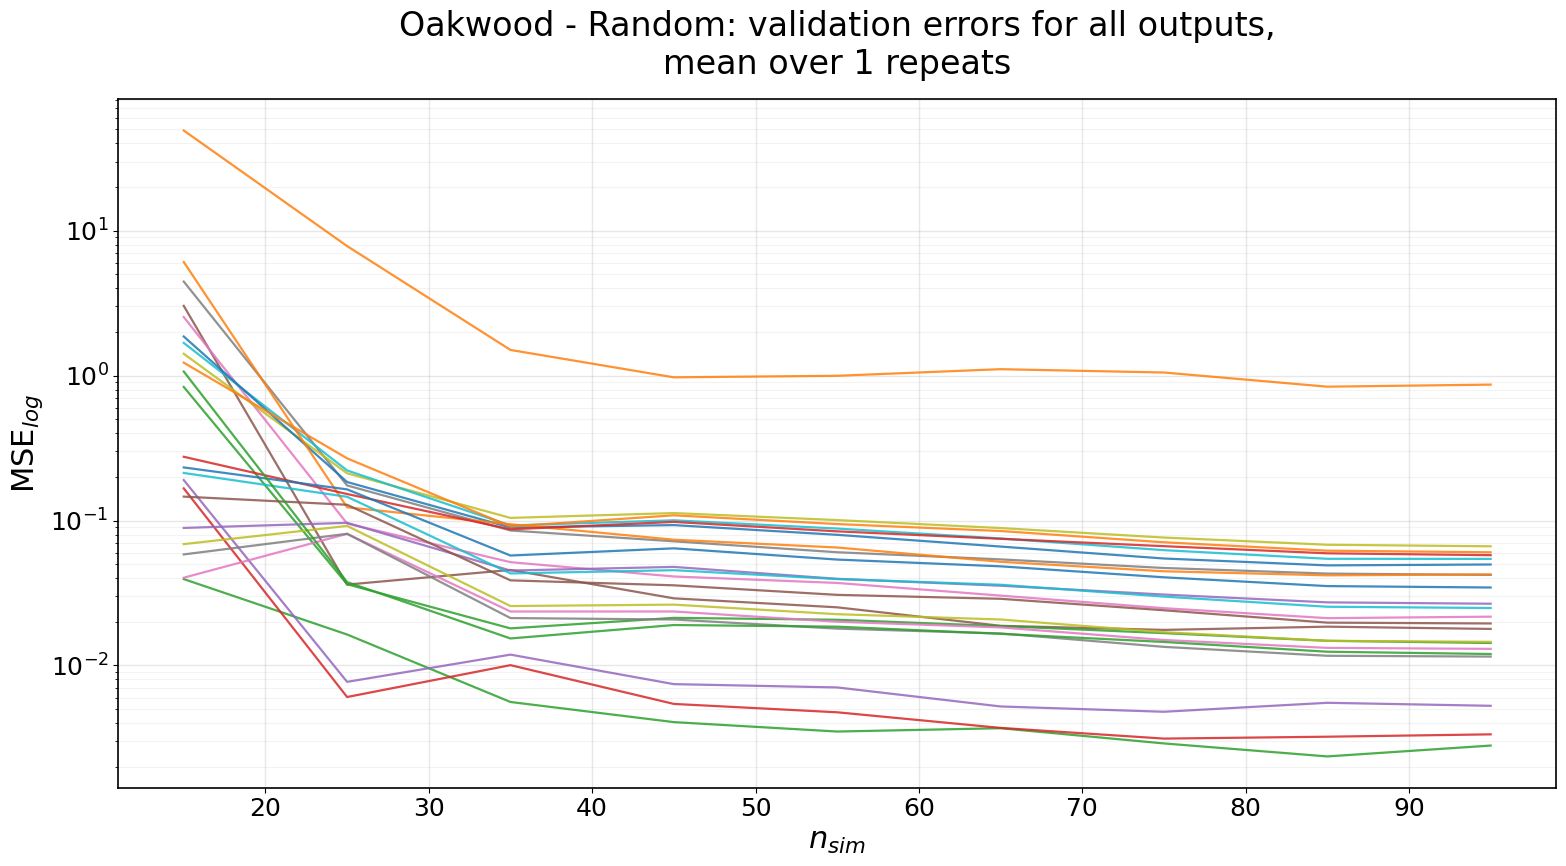

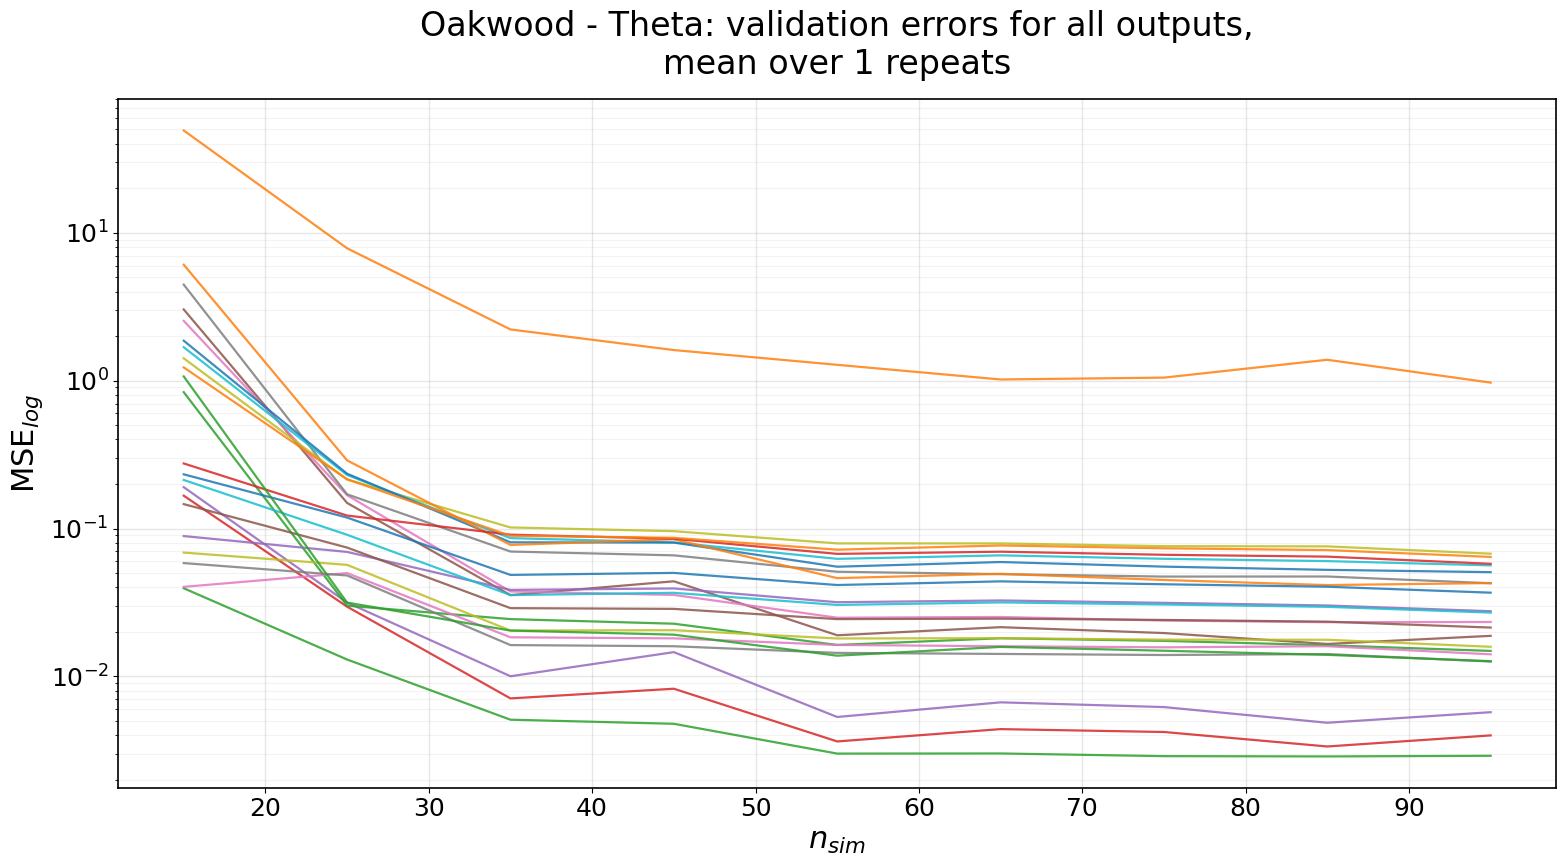

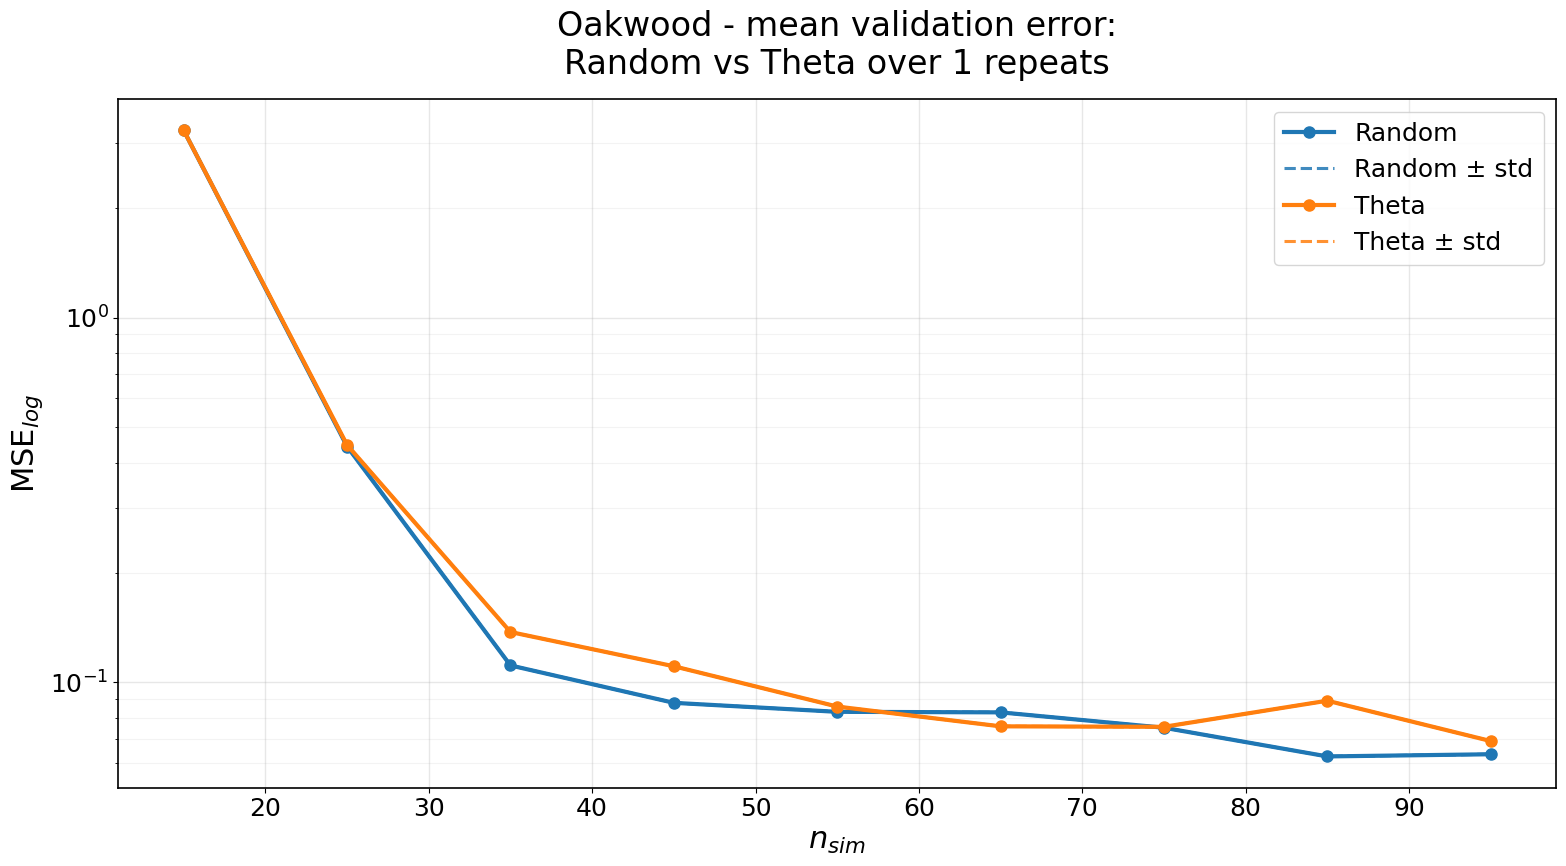

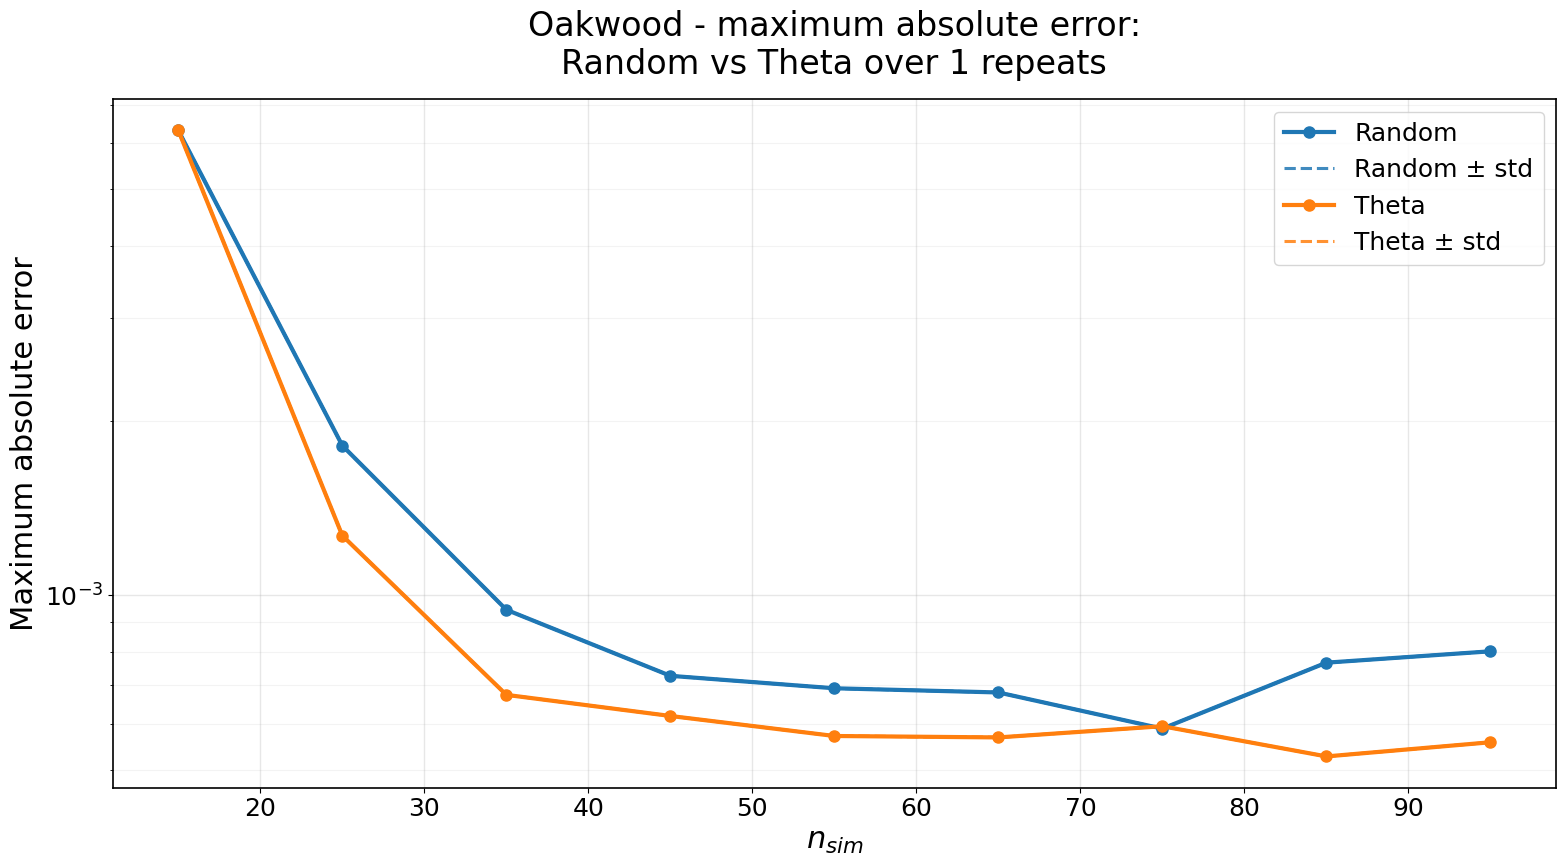

plots_output


In [18]:
# ============================================================
# Grafy
# ============================================================

import os
import re

# ------------------------------------------------------------
# Složka pro ukládání obrázků
# ------------------------------------------------------------

PLOTS_DIR = "plots_output"
os.makedirs(PLOTS_DIR, exist_ok=True)

SAVE_DPI = 300


def safe_filename(text):
    """Bezpečný název souboru bez mezer a speciálních znaků."""
    text = str(text)
    text = text.replace(" ", "_")
    text = re.sub(r"[^A-Za-z0-9_\-]+", "", text)
    return text


def save_current_figure(fig, dataset_name, plot_name):
    """Uloží aktuální obrázek do složky PLOTS_DIR."""
    filename = f"{safe_filename(dataset_name)}_{safe_filename(plot_name)}.png"
    filepath = os.path.join(PLOTS_DIR, filename)

    fig.savefig(
        filepath,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white"
    )


# Globální nastavení velikostí pro prezentaci
PRESENTATION_FIGSIZE = (16, 9)

TITLE_SIZE = 24
LABEL_SIZE = 22
TICK_SIZE = 18
LEGEND_SIZE = 18

MAIN_LINEWIDTH = 3.0
STD_LINEWIDTH = 2.2
ALL_OUTPUT_LINEWIDTH = 1.6
MARKER_SIZE = 8

# Metody, které se mají opravdu vykreslovat.
# LHS zde záměrně není.
PLOT_METHODS = ["Random", "Theta"]

plt.rcParams.update({
    "font.size": TICK_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
})


def format_presentation_axes(ax):
    """Jednotné formátování grafu pro prezentaci."""
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
    ax.tick_params(axis="both", which="minor", labelsize=TICK_SIZE - 2)

    ax.grid(True, which="major", alpha=0.30, linewidth=1.0)
    ax.grid(True, which="minor", alpha=0.15, linewidth=0.8)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


def plot_mean_with_band(ax, x, curves, label):
    curves = np.asarray(curves, dtype=float)

    mean = np.nanmean(curves, axis=0)
    std = np.nanstd(curves, axis=0)

    lower = mean - std
    upper = mean + std

    # --------------------------------------------------------
    # Na logaritmické ose nelze vykreslit hodnoty <= 0.
    # Aby se čára směrodatné odchylky nikdy nepřerušila,
    # hodnoty <= 0 se oříznou na malou kladnou hodnotu.
    # --------------------------------------------------------

    positive_values = np.concatenate([
        mean[np.isfinite(mean) & (mean > 0)],
        lower[np.isfinite(lower) & (lower > 0)],
        upper[np.isfinite(upper) & (upper > 0)],
    ])

    if positive_values.size > 0:
        log_floor = np.nanmin(positive_values) * 0.50
    else:
        log_floor = 1e-12

    lower = np.where(np.isfinite(lower), lower, log_floor)
    upper = np.where(np.isfinite(upper), upper, log_floor)

    lower = np.maximum(lower, log_floor)
    upper = np.maximum(upper, log_floor)

    # Hlavní křivka = průměr
    line, = ax.plot(
        x,
        mean,
        marker="o",
        markersize=MARKER_SIZE,
        linewidth=MAIN_LINEWIDTH,
        label=label
    )

    # Barva dané metody
    color = line.get_color()

    # Dolní okraj = mean - směrodatná odchylka
    ax.plot(
        x,
        lower,
        linestyle="--",
        linewidth=STD_LINEWIDTH,
        color=color,
        alpha=0.85,
        label=f"{label} ± std"
    )

    # Horní okraj = mean + směrodatná odchylka
    ax.plot(
        x,
        upper,
        linestyle="--",
        linewidth=STD_LINEWIDTH,
        color=color,
        alpha=0.85,
        label="_nolegend_"
    )


for dataset_name, repeats in all_outputs.items():

    # ========================================================
    # 1) Graf všech výstupních křivek pro Random
    #    průměr přes opakování
    # ========================================================

    random_stack = np.asarray([
        rep["errs_by_method"]["Random"]
        for rep in repeats
    ])  # repeat x n_train x n_outputs

    errs_random_mean_outputs = np.nanmean(random_stack, axis=0)

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)

    for j in range(errs_random_mean_outputs.shape[1]):
        ax.plot(
            nsim,
            errs_random_mean_outputs[:, j],
            linewidth=ALL_OUTPUT_LINEWIDTH,
            alpha=0.85
        )

    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$", fontsize=LABEL_SIZE)
    ax.set_xlabel("$n_{sim}$", fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dataset_name} - Random: validation errors for all outputs,\n"
        f"mean over {N_REPEATS} repeats",
        fontsize=TITLE_SIZE,
        pad=18
    )

    format_presentation_axes(ax)

    plt.tight_layout()

    save_current_figure(
        fig,
        dataset_name,
        "01_Random_all_output_validation_errors"
    )

    plt.show()


    # ========================================================
    # 2) Graf všech výstupních křivek pro Theta
    #    průměr přes opakování
    # ========================================================

    theta_stack = np.asarray([
        rep["errs_by_method"]["Theta"]
        for rep in repeats
    ])  # repeat x n_train x n_outputs

    errs_theta_mean_outputs = np.nanmean(theta_stack, axis=0)

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)

    for j in range(errs_theta_mean_outputs.shape[1]):
        ax.plot(
            nsim,
            errs_theta_mean_outputs[:, j],
            linewidth=ALL_OUTPUT_LINEWIDTH,
            alpha=0.85
        )

    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$", fontsize=LABEL_SIZE)
    ax.set_xlabel("$n_{sim}$", fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dataset_name} - Theta: validation errors for all outputs,\n"
        f"mean over {N_REPEATS} repeats",
        fontsize=TITLE_SIZE,
        pad=18
    )

    format_presentation_axes(ax)

    plt.tight_layout()

    save_current_figure(
        fig,
        dataset_name,
        "02_Theta_all_output_validation_errors"
    )

    plt.show()


    # ========================================================
    # 3) Porovnání mean Random vs Theta
    #    se směrodatnou odchylkou
    # ========================================================

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)

    for method in PLOT_METHODS:
        mean_curves = [
            np.nanmean(rep["errs_by_method"][method], axis=1)
            for rep in repeats
        ]  # repeat x n_train

        plot_mean_with_band(ax, nsim, mean_curves, method)

    ax.set_yscale("log")
    ax.set_ylabel("MSE$_{log}$", fontsize=LABEL_SIZE)
    ax.set_xlabel("$n_{sim}$", fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dataset_name} - mean validation error:\n"
        f"Random vs Theta over {N_REPEATS} repeats",
        fontsize=TITLE_SIZE,
        pad=18
    )

    ax.legend(fontsize=LEGEND_SIZE, frameon=True)
    format_presentation_axes(ax)

    plt.tight_layout()

    save_current_figure(
        fig,
        dataset_name,
        "03_Random_vs_Theta_mean_validation_error_std"
    )

    plt.show()


    # ========================================================
    # 4) Maximum absolute error: Random vs Theta
    #    se směrodatnou odchylkou
    # ========================================================

    fig, ax = plt.subplots(figsize=PRESENTATION_FIGSIZE)

    for method in PLOT_METHODS:
        max_abs_curves = [
            np.nanmax(rep["max_abs_by_method"][method], axis=1)
            for rep in repeats
        ]  # repeat x n_train

        plot_mean_with_band(ax, nsim, max_abs_curves, method)

    ax.set_yscale("log")
    ax.set_ylabel("Maximum absolute error", fontsize=LABEL_SIZE)
    ax.set_xlabel("$n_{sim}$", fontsize=LABEL_SIZE)
    ax.set_title(
        f"{dataset_name} - maximum absolute error:\n"
        f"Random vs Theta over {N_REPEATS} repeats",
        fontsize=TITLE_SIZE,
        pad=18
    )

    ax.legend(fontsize=LEGEND_SIZE, frameon=True)
    format_presentation_axes(ax)

    plt.tight_layout()

    save_current_figure(
        fig,
        dataset_name,
        "04_Random_vs_Theta_maximum_absolute_error_std"
    )

    plt.show()


print(PLOTS_DIR)

# Vykreslení tunelu (posuny)

In [20]:

def fit_model_at_single(dataset_name, method, n_train, repeat_id=0):
    out = all_outputs[dataset_name][repeat_id]
    data_file = [
        f for f in DATA_FILES
        if os.path.splitext(os.path.basename(f))[0] == dataset_name
    ][0]

    # verbose=False, ať se při každém refitu znovu nevypisuje hláška
    # o vyřazených (skoro) konstantních výstupech.
    X, Y_reduced, keep_mask, y_col_names, Y_full = load_dataset(data_file, verbose=False)

    if method == "Random":
        order = out["prefix_train_pool"]
    elif method == "Theta":
        order = out["theta_full_order"]
    else:
        raise ValueError(f"Unknown method: {method}")

    train_idx = np.asarray(order[:n_train], dtype=int)
    test_idx = np.asarray(out["test_idx"], dtype=int)

    Xtr = X[train_idx]
    Ytr_reduced = Y_reduced[train_idx]
    Xte = X[test_idx]
    Yte_reduced = Y_reduced[test_idx]

    # --- přesně ta konfigurace, co už byla vybraná pro tenhle (method, n_train) ---
    res = out["results"]
    row = res[(res["method"] == method) & (res["n_train"] == n_train)]
    if row.empty or row.iloc[0][["degree", "cond_limit", "ratio_limit", "cr"]].isna().any():
        raise RuntimeError(
            f"No stored best config for {dataset_name}/{method}/n_train={n_train} "
            f"(repeat_id={repeat_id})."
        )
    row = row.iloc[0]

    fitted = fit_one_config(
        Xtr, Ytr_reduced, Xte, Yte_reduced,
        row["degree"], row["cond_limit"], row["ratio_limit"], row["cr"],
        return_model=True,
    )

    mean_active, var_active = fitted["sapce"].pce.get_moments()
    std_active = np.sqrt(var_active)

    # Sestav plné pole přes VŠECH n_outputs_full výstupů - (skoro) konstantní
    # výstupy (jako U_251_1) nemají PCE model, doplní se přímo z dat (jsou
    # prakticky konstantní, takže mean/std z celého datasetu je pro ně
    # rozumný a stabilní odhad).
    n_full = len(y_col_names)
    mean_full = np.zeros(n_full)
    std_full = np.zeros(n_full)
    mean_full[keep_mask] = mean_active
    std_full[keep_mask] = std_active

    excluded_idx = np.where(~keep_mask)[0]
    if excluded_idx.size > 0:
        mean_full[excluded_idx] = np.mean(Y_full[:, excluded_idx], axis=0)
        std_full[excluded_idx] = np.std(Y_full[:, excluded_idx], axis=0)

    return mean_full, std_full, y_col_names


# Zprůměruje mean/std posunů přes VŠECHNY dostupné repeaty (N_REPEATS) -
# repeaty bez uloženého platného modelu pro danou kombinaci se přeskočí
# s varováním, místo aby spadla celá buňka (stejný princip jako
# fit_model_averaged ve verzi pro Oakwood_NVM/N/V/M).
def fit_model_averaged_single(dataset_name, method, n_train, verbose=True):
    n_repeats_available = len(all_outputs[dataset_name])

    mean_list, std_list = [], []
    y_col_names_ref = None
    skipped = []

    for repeat_id in range(n_repeats_available):
        try:
            mean_full, std_full, y_col_names_ref = fit_model_at_single(
                dataset_name, method, n_train, repeat_id=repeat_id
            )
        except RuntimeError:
            skipped.append(repeat_id)
            continue

        mean_list.append(mean_full)
        std_list.append(std_full)

    if not mean_list:
        raise RuntimeError(
            f"Žádný z {n_repeats_available} repeatů nemá platný uložený model pro "
            f"{dataset_name}/{method}/n_train={n_train}."
        )

    if verbose and skipped:
        print(
            f"[fit_model_averaged_single] {dataset_name}/{method}/n_train={n_train}: "
            f"přeskočeno {len(skipped)}/{n_repeats_available} repeatů bez platného "
            f"modelu (repeat_id={skipped}), zprůměrováno přes zbývajících "
            f"{len(mean_list)}."
        )

    mean_avg = np.mean(mean_list, axis=0)
    std_avg = np.mean(std_list, axis=0)

    # column -> (mean, std), stejný tvar jako _mean_map v Posuny_vykresleni.ipynb
    return dict(zip(y_col_names_ref, zip(mean_avg, std_avg)))


,ID,mean |u| [m],3σ [mm],mean ux [m],mean uy [m],Skupina
0,306,0.000289,0.752807,0.000000e+00,-0.000289,Povrch
1,308,0.003511,0.702285,0.000000e+00,-0.003511,Povrch
2,310,0.011641,1.447876,0.000000e+00,-0.011641,Povrch
3,311,0.018053,2.210854,0.000000e+00,-0.018053,Povrch
4,312,0.024705,3.410297,0.000000e+00,-0.024705,Povrch
5,313,0.028046,4.181129,0.000000e+00,-0.028046,Povrch
6,314,0.023977,3.690346,0.000000e+00,-0.023977,Povrch
7,315,0.016317,2.446993,0.000000e+00,-0.016317,Povrch
8,316,0.010633,1.673722,0.000000e+00,-0.010633,Povrch
9,318,0.003325,0.780475,0.000000e+00,-0.003325,Povrch


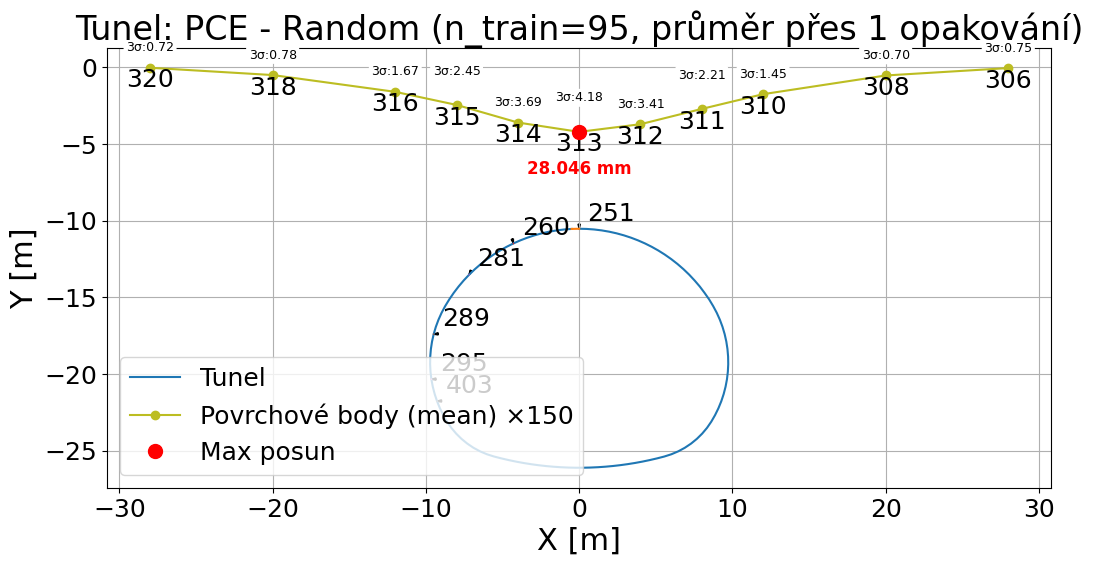

,ID,mean |u| [m],3σ [mm],mean ux [m],mean uy [m],Skupina
0,306,0.000287,0.750741,0.000000e+00,-0.000287,Povrch
1,308,0.003501,0.709438,0.000000e+00,-0.003501,Povrch
2,310,0.011625,1.492271,0.000000e+00,-0.011625,Povrch
3,311,0.018031,2.261183,0.000000e+00,-0.018031,Povrch
4,312,0.024675,3.464909,0.000000e+00,-0.024675,Povrch
5,313,0.028010,4.236809,0.000000e+00,-0.028010,Povrch
6,314,0.023945,3.745993,0.000000e+00,-0.023945,Povrch
7,315,0.016293,2.490464,0.000000e+00,-0.016293,Povrch
8,316,0.010621,1.711968,0.000000e+00,-0.010621,Povrch
9,318,0.003321,0.790942,0.000000e+00,-0.003321,Povrch


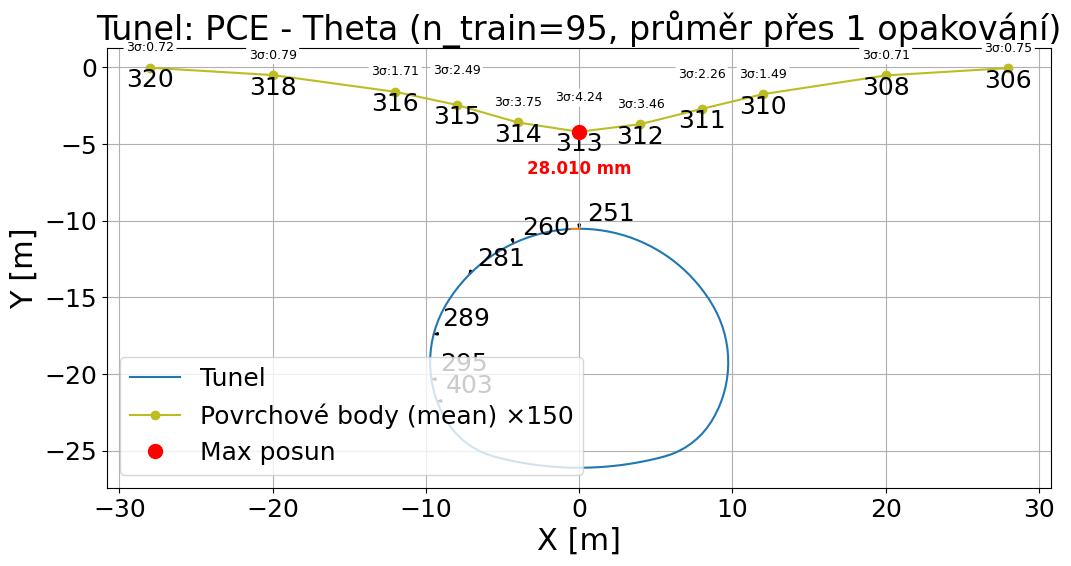

In [21]:
# Geometrie tunelu (113 bodů) - stejná jako v Posuny_vykresleni.ipynb
nodes = np.array([
    (0, -10.5275), (0.492, -10.5395), (0.983, -10.5755), (1.4719, -10.6353),
    (1.95708, -10.719), (2.43761, -10.8261), (2.91235, -10.9566), (3.38016, -11.1101),
    (3.83994, -11.2861), (4.29059, -11.4844), (4.73104, -11.7044), (5.16024, -11.9456),
    (5.57717, -12.2075), (6.00215, -12.505), (6.41129, -12.824), (6.80351, -13.1636),
    (7.17776, -13.5229), (7.53, -13.901), (7.87, -14.2968), (8.18, -14.7093),
    (8.48, -15.1374), (8.74685, -15.58), (8.97931, -16.0164), (9.18182, -16.4675),
    (9.35346, -16.9312), (9.49344, -17.4055), (9.60113, -17.8881), (9.67604, -18.3768),
    (9.71783, -18.8695), (9.7263, -19.3639), (9.70142, -19.8578), (9.64331, -20.3488),
    (9.55222, -20.8348), (9.42857, -21.3136), (9.27246, -21.7842), (9.08488, -22.2431),
    (8.86671, -22.6884), (8.61894, -23.1179), (8.34143, -23.5199), (8.02741, -23.8942),
    (7.67966, -24.2374), (7.30124, -24.5464), (6.89548, -24.8185), (6.46599, -25.0513),
    (6.01653, -25.2428), (5.55109, -25.3913), (5.07787, -25.5123), (4.60202, -25.6225),
    (4.12377, -25.7219), (3.6434, -25.8104), (3.16338, -25.8875), (2.68174, -25.9538),
    (2.19873, -26.0091), (1.71458, -26.0534), (1.22955, -26.0868), (0.744, -26.1092),
    (0.258, -26.1205), (-0.228, -26.1209), (-0.714, -26.1102), (-1.20007, -26.0885),
    (-1.68514, -26.0558), (-2.16935, -26.0121), (-2.65244, -25.9574), (-3.13417, -25.8919),
    (-3.61429, -25.8154), (-4.10204, -25.7262), (-4.58759, -25.6257), (-5.07, -25.5141),
    (-5.55, -25.3913), (-6.01653, -25.2428), (-6.47, -25.0513), (-6.90, -24.8185),
    (-7.30124, -24.5464), (-7.67966, -24.2374), (-8.02741, -23.8942), (-8.34143, -23.5199),
    (-8.61894, -23.1179), (-8.86671, -22.6884), (-9.08488, -22.2431), (-9.27246, -21.7842),
    (-9.42857, -21.3136), (-9.55222, -20.8348), (-9.64331, -20.3488), (-9.70142, -19.8578),
    (-9.7263, -19.3639), (-9.71783, -18.8695), (-9.67604, -18.3768), (-9.60113, -17.8881),
    (-9.49344, -17.4055), (-9.35346, -16.9312), (-9.18182, -16.4675), (-8.97931, -16.0164),
    (-8.74685, -15.58), (-8.47618, -15.1374), (-8.18314, -14.7093), (-7.86849, -14.2968),
    (-7.53307, -13.901), (-7.17776, -13.5229), (-6.80351, -13.1636), (-6.41129, -12.824),
    (-6.00215, -12.505), (-5.57717, -12.2075), (-5.16024, -11.9456), (-4.73104, -11.7044),
    (-4.29059, -11.4844), (-3.83994, -11.2861), (-3.38016, -11.1101), (-2.91235, -10.9566),
    (-2.43761, -10.8261), (-1.95708, -10.719), (-1.4719, -10.6353), (-0.983, -10.5755),
    (-0.492, -10.5395)
], dtype=float)

# Body na obvodu tunelu (x/y posun, U_<id>_1 a U_<id>_2)
A_points = {
    251: (0.0, -10.5275), 260: (-4.29059, -11.4844), 281: (-7.17776, -13.5229),
    289: (-9.49344, -17.4055), 295: (-9.64331, -20.3488), 403: (-9.27246, -21.7842),
}
A_cols_x = {uid: f"U_{uid}_1" for uid in A_points}
A_cols_y = {uid: f"U_{uid}_2" for uid in A_points}

# Body na povrchu (svislý posun, U_<id>_19.2)
B_points = {
    320: (-28.0, 0.0), 318: (-20.0, 0.0), 316: (-12.0, 0.0), 315: (-8.0, 0.0),
    314: (-4.0, 0.0), 313: (0.0, 0.0), 312: (4.0, 0.0), 311: (8.0, 0.0),
    310: (12.0, 0.0), 308: (20.0, 0.0), 306: (28.0, 0.0),
}
B_cols = {uid: f"U_{uid}_19.2" for uid in B_points}

SURFACE_SCALE_TUNNEL = 150.0
PLOT_N_TRAIN_TUNNEL = int(np.max(nsim))  # nejvyšší dostupné n_train = nejvíc dat


def plot_tunnel_pce(dataset_name, method, n_train):
    mean_map = fit_model_averaged_single(dataset_name, method, n_train)

    def get_mean_std(name):
        return mean_map.get(name, (np.nan, np.nan))

    center = nodes.mean(axis=0)

    # --- Statistiky bodů na obvodu tunelu (vektorový posun) ---
    A_stats = {}
    for uid in A_points:
        mx, sx = get_mean_std(A_cols_x[uid])
        my, sy = get_mean_std(A_cols_y[uid])
        mean_vec = np.array([mx, my], dtype=float)
        mean_mag = float(np.linalg.norm(mean_vec))
        std_mag = float(np.sqrt(
            (sx if np.isfinite(sx) else 0.0) ** 2 +
            (sy if np.isfinite(sy) else 0.0) ** 2
        ))
        three_sigma = 3.0 * std_mag
        A_stats[uid] = (mean_mag, three_sigma, mean_vec)

    # --- Statistiky bodů na povrchu (skalární svislý posun) ---
    B_stats = {}
    for uid in B_points:
        m, s = get_mean_std(B_cols[uid])
        if np.isfinite(m) and np.isfinite(s):
            B_stats[uid] = (float(m), 3.0 * float(s))

    plt.figure(figsize=(11, 7))

    # Obrys tunelu
    plt.plot(nodes[:, 0], nodes[:, 1], label="Tunel")
    plt.plot([nodes[-1, 0], nodes[0, 0]], [nodes[-1, 1], nodes[0, 1]])

    # Body na obvodu tunelu - šipka mean posunu + úsečka ±3σ ve směru posunu
    end_means_A = {}
    for uid, (x, y) in A_points.items():
        mean_mag, three_sigma, mean_vec = A_stats[uid]
        start = np.array([x, y])
        end_mean = start + mean_vec
        end_means_A[uid] = end_mean.copy()

        d = end_mean - start
        n = np.linalg.norm(d)
        if n < 1e-12:
            v = start - center
            d = v / (np.linalg.norm(v) + 1e-12)
        else:
            d = d / n

        plt.arrow(start[0], start[1], *(end_mean - start),
                  length_includes_head=True, head_width=0.15, head_length=0.3)
        seg0 = end_mean - three_sigma * d
        seg1 = end_mean + three_sigma * d
        plt.plot([seg0[0], seg1[0]], [seg0[1], seg1[1]], linewidth=1)
        plt.annotate(str(uid), (x, y), xytext=(6, 6), textcoords="offset points")

    # Body na povrchu - propadová křivka (mean × SURFACE_SCALE_TUNNEL) + 3σ popisky
    xs, ys, labels, sigmas = [], [], [], []
    for uid, (x, y) in B_points.items():
        if uid not in B_stats:
            continue
        mean, three_sigma = B_stats[uid]
        xs.append(x)
        ys.append(y + mean * SURFACE_SCALE_TUNNEL)
        labels.append(uid)
        sigmas.append(three_sigma)

    if xs:
        plt.plot(xs, ys, '-o', label=f"Povrchové body (mean) ×{int(SURFACE_SCALE_TUNNEL)}")
        for i, (x, y, uid, s) in enumerate(zip(xs, ys, labels, sigmas)):
            plt.annotate(str(uid), (x, y), xytext=(0, -14), textcoords="offset points", ha="center")
            if uid in (318, 308):
                offset_y = 12
            else:
                offset_y = 12 if i % 2 == 0 else 22
            plt.annotate(
                f"3σ:{s * 1000:.2f}",
                (x, y),
                xytext=(0, offset_y),
                textcoords="offset points",
                ha="center",
                fontsize=9,
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=1.0)
            )

    # --- Souhrnná tabulka + zvýraznění maxima ---
    rows = []
    for uid, st in A_stats.items():
        rows.append({
            "ID": uid, "mean |u| [m]": st[0], "3σ [mm]": st[1] * 1000,
            "mean ux [m]": st[2][0], "mean uy [m]": st[2][1], "Skupina": "Tunel",
        })
    for uid, st in B_stats.items():
        rows.append({
            "ID": uid, "mean |u| [m]": abs(st[0]), "3σ [mm]": st[1] * 1000,
            "mean ux [m]": 0, "mean uy [m]": st[0], "Skupina": "Povrch",
        })
    summary_df_tunnel = pd.DataFrame(rows).sort_values(["Skupina", "ID"]).reset_index(drop=True)

    try:
        from IPython.display import display
        display(summary_df_tunnel)
    except Exception:
        print(summary_df_tunnel.to_string(index=False))

    if not summary_df_tunnel.empty and summary_df_tunnel["mean |u| [m]"].notna().any():
        idx_max = summary_df_tunnel["mean |u| [m]"].idxmax()
        max_row = summary_df_tunnel.loc[idx_max]
        max_id = int(max_row["ID"])
        max_val_mm = float(max_row["mean |u| [m]"]) * 1000.0

        px = py = None
        if max_id in A_points:
            px, py = end_means_A[max_id]
        elif max_id in B_points:
            base_x, base_y = B_points[max_id]
            mean_val = float(max_row["mean uy [m]"])
            px, py = base_x, base_y + mean_val * SURFACE_SCALE_TUNNEL

        if px is not None:
            plt.plot(px, py, 'o', color='red', markersize=10, zorder=5, label="Max posun")
            plt.annotate(
                f"{max_val_mm:.3f} mm",
                (px, py),
                xytext=(0, -30),
                textcoords="offset points",
                color="red",
                fontsize=12,
                fontweight="bold",
                ha="center",
            )

    n_repeats_used = len(all_outputs[dataset_name])
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True)
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title(f"Tunel: PCE - {method} (n_train={n_train}, průměr přes {n_repeats_used} opakování)")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()


for method in METHODS:
    plot_tunnel_pce("Oakwood", method, PLOT_N_TRAIN_TUNNEL)
